# Abaqus UMAT <-> ANSYS USERMAT cross-check / Abaqus UMAT と ANSYS USERMAT の相互検証

**EN.** This is the thesis's core portability/correctness claim: the ANSYS
`USERMAT` port reproduces the already-verified Abaqus `UMAT` **constitutive
core** -- not a re-implementation compared against itself, but the two
**actual Fortran source files** (`umat_biofilm_visco.f`,
`usermat_biofilm.f`), compiled and driven directly. The two solvers use
different Voigt shear orderings (Abaqus `12,13,23` vs. ANSYS `12,23,13`);
this notebook reconstructs the full 3x3 Cauchy stress tensor from each and
compares tensors, not raw component order.

**JA.** これは修士論文における移植性・正当性の核心的な主張です: ANSYSの
`USERMAT`移植版が、既に検証済みのAbaqus `UMAT`の**構成則コア**を再現する
ことを示します -- 自己比較のための再実装ではなく、**実際の2つのFortran
ソースファイル**(`umat_biofilm_visco.f`、`usermat_biofilm.f`)そのものを
コンパイルして直接駆動します。2つのソルバーはVoigtのせん断成分順序が異なる
ため(Abaqus: `12,13,23` / ANSYS: `12,23,13`)、このノートブックは両方から
完全な3x3コーシー応力テンソルを再構成した上で、生の成分順序ではなく
テンソルそのものを比較します。

Requires `gfortran` + `numpy`. No licensed Abaqus/ANSYS needed -- both
constitutive cores are plain Fortran, compiled fresh below.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
GOOD = "#0ca30c"
BAD = "#c23b3b"
GRID = "#e1e0d9"

sys.path.insert(0, str(Path.cwd()))  # this notebook lives in ansys_usermat/crosscheck/
import crosscheck
import adversarial

print("left (Abaqus):", crosscheck._ABQ_SRC)
print("right (ANSYS):", crosscheck._ANS_SRC)
for p in (crosscheck._ABQ_SRC, crosscheck._ANS_SRC):
    assert p.exists(), f"missing {p}"

left (Abaqus): C:\Users\nishioka\git\pde-fem-biofilm\umat_biofilm_visco.f
right (ANSYS): C:\Users\nishioka\git\pde-fem-biofilm\ansys_usermat\usermat_biofilm.f


## Curated battery: 20 cases / 厳選20ケース

**EN.** Identity+growth, uniaxial, shear, elastic (`eta=0`), frozen
(`eta` huge), large growth, no growth, Mooney-Rivlin, and 12 random
finite-strain states with a random prior viscous state `Fv`. Compiles both
cores fresh (temp dir) and runs one process per case.

**JA.** identity+growth、単軸、せん断、弾性(`eta=0`)、凍結(`eta`巨大)、
大成長、無成長、Mooney-Rivlin、および12個のランダム有限ひずみ状態(粘性内部
変数`Fv`の初期値もランダム)。両コアを一時ディレクトリで新規コンパイルし、
ケースごとに1プロセスを実行します。

In [2]:
import tempfile

with tempfile.TemporaryDirectory() as td:
    xleft, xright = crosscheck._build_pair(
        Path(td),
        crosscheck._HERE / "xcheck_driver_abq.f", crosscheck._ABQ_SRC,
        crosscheck._HERE / "xcheck_driver_ans.f", crosscheck._ANS_SRC,
        crosscheck._ABA_INC,
    )
    curated_rows = []
    for name, F, Fv, params in crosscheck._cases():
        sa, fva, da = crosscheck._run(xleft, F, Fv, params)
        sb, fvb, db = crosscheck._run(xright, F, Fv, params)
        d_sig = np.abs(crosscheck._tensor(sa, crosscheck.ABQ_MAP) - crosscheck._tensor(sb, crosscheck.ANS_MAP)).max()
        d_fv = np.abs(fva - fvb).max()
        d_det = abs(da - db)
        curated_rows.append((name, d_sig, d_fv, d_det))

worst_curated = max(max(r[1:]) for r in curated_rows)
print(f"{'case':<20}{'|dSigma|':>12}{'|dFv|':>12}{'|dJe|':>12}")
for name, ds, df, dd in curated_rows:
    print(f"{name:<20}{ds:>12.2e}{df:>12.2e}{dd:>12.2e}")
print(f"\nworst over {len(curated_rows)} curated cases: {worst_curated:.2e}")
assert worst_curated < 1e-11, "curated battery: cores disagree beyond machine precision"

case                    |dSigma|       |dFv|       |dJe|
identity+growth         0.00e+00    0.00e+00    0.00e+00
uniaxial                0.00e+00    0.00e+00    0.00e+00
simple shear            0.00e+00    0.00e+00    0.00e+00
elastic (eta=0)         0.00e+00    0.00e+00    0.00e+00
frozen (eta huge)       0.00e+00    0.00e+00    0.00e+00
large growth            0.00e+00    0.00e+00    0.00e+00
no growth               0.00e+00    0.00e+00    0.00e+00
Mooney-Rivlin           0.00e+00    0.00e+00    0.00e+00
random#0                0.00e+00    0.00e+00    0.00e+00
random#1                0.00e+00    0.00e+00    0.00e+00
random#2                0.00e+00    0.00e+00    0.00e+00
random#3                0.00e+00    0.00e+00    0.00e+00
random#4                0.00e+00    0.00e+00    0.00e+00
random#5                0.00e+00    0.00e+00    0.00e+00
random#6                0.00e+00    0.00e+00    0.00e+00
random#7                0.00e+00    0.00e+00    0.00e+00
random#8                0.00e+0

## Adversarial hunt: pathological battery + wide fuzz / 敵対的探索: 病的ケース+広域ファズ

**EN.** `crosscheck.py` confirms 20 nice states; `adversarial.py` instead
*hunts* for a state where the two cores diverge -- 17 curated pathological
cases (each pins one branch to an extreme: near-incompressible, near-singular
`Fe`, Mooney-Rivlin, elastic/frozen viscous limits, shrinkage/extreme growth,
tiny/huge `dt`, large shear in each Voigt plane, pure rotation, sheared prior
`Fv`) plus a wide random fuzz sweep over every material parameter. Both use
a **batched** driver (one process, thousands of cases via stdin) so this runs
in seconds rather than minutes. `README.md` reports 8017 cases at `n=8000`;
this notebook runs a smaller `n` by default so it stays fast to re-execute --
bump `N_FUZZ` for the full sweep.

**JA.** `crosscheck.py`は20個の穏当な状態で一致を確認するのに対し、
`adversarial.py`は2つのコアが食い違う状態を**探しに行きます** -- 17個の
厳選された病的ケース(それぞれ1つの分岐を極端に振る: 非圧縮に近い、`Fe`が
特異に近い、Mooney-Rivlin、弾性/凍結粘性極限、収縮/極端成長、極小/極大
`dt`、各Voigt平面での大せん断、純回転、初期`Fv`にせん断)に加え、全物性
パラメータにわたる広域ランダムファズ。どちらも**バッチ化**ドライバ(1
プロセスでstdin経由数千ケース)を使うため数分ではなく数秒で完了します。
`README.md`では`n=8000`で8017ケースを報告済み; このノートブックは再実行を
速く保つためデフォルトで小さめの`n`を使います -- フルスイープには`N_FUZZ`
を増やしてください。

In [3]:
N_FUZZ = 2000  # README's full sweep uses 8000; bump this to reproduce that exactly
SEED = 12345

with tempfile.TemporaryDirectory() as td:
    xabq, xans = adversarial.build(Path(td))

    rng = np.random.default_rng(SEED)
    path_cases = adversarial.pathological_cases()
    fuzz = adversarial.fuzz_cases(rng, N_FUZZ)
    all_cases = [(F, Fv, p) for _name, F, Fv, p in path_cases] + fuzz

    rows_abq = adversarial.run_batch(xabq, all_cases)
    rows_ans = adversarial.run_batch(xans, all_cases)
    deltas = adversarial.compare(rows_abq, rows_ans)

    n_path = len(path_cases)
    path_deltas = deltas[:n_path]
    fuzz_deltas = deltas[n_path:]

    obj_abq = adversarial.objectivity(xabq, np.random.default_rng(SEED + 1))
    obj_ans = adversarial.objectivity(xans, np.random.default_rng(SEED + 1))

print(f"pathological battery: {n_path} cases, worst |Delta| = {path_deltas.max():.3e}")
for (name, *_), d in zip(path_cases, path_deltas):
    flag = "" if d < adversarial.EXACT_TOL else "  <-- EXCEEDS TOLERANCE"
    print(f"  {name:<22} {d:.2e}{flag}")
print(f"\nwide fuzz: {N_FUZZ} cases, worst |Delta| = {fuzz_deltas.max():.3e}")
print(f"non-finite outputs: {int((~np.isfinite(deltas)).sum())}")
print(f"\nframe indifference (elastic limit, per core): Abaqus={obj_abq:.2e}  ANSYS={obj_ans:.2e}")

assert deltas.max() < adversarial.EXACT_TOL, "adversarial sweep found a disagreement"
assert np.isfinite(deltas).all(), "non-finite output somewhere in the sweep"
print("\nPASS: equivalence holds across the full sweep, zero non-finite outputs.")

pathological battery: 17 cases, worst |Delta| = 0.000e+00
  near-incompressible    0.00e+00
  very-soft-volum.       0.00e+00
  near-singular-F        0.00e+00
  shrinkage alpha->-1    0.00e+00
  extreme growth         0.00e+00
  MR near-incompr.       0.00e+00
  MR + shear12           0.00e+00
  shear12 large          0.00e+00
  shear13 large          0.00e+00
  shear23 large          0.00e+00
  pure rotation          0.00e+00
  rotation+growth        0.00e+00
  tiny dt                0.00e+00
  huge dt                0.00e+00
  eta->0 elastic         0.00e+00
  eta huge frozen        0.00e+00
  prior Fv sheared       0.00e+00

wide fuzz: 2000 cases, worst |Delta| = 0.000e+00
non-finite outputs: 0

frame indifference (elastic limit, per core): Abaqus=4.86e-17  ANSYS=4.86e-17

PASS: equivalence holds across the full sweep, zero non-finite outputs.


## Visualize: discrepancy across every case / 全ケースの不一致を可視化

**EN.** Everything should sit at or near floating-point zero. The dashed
line is `EXACT_TOL` (1e-11) -- the equivalence threshold used by both
`crosscheck.py`'s CI test and `adversarial.py`'s pass/fail call.

**JA.** 全て浮動小数点ゼロ付近に位置するはずです。破線は`EXACT_TOL`
(1e-11) -- `crosscheck.py`のCIテストと`adversarial.py`の合否判定の両方が
使う一致判定のしきい値です。

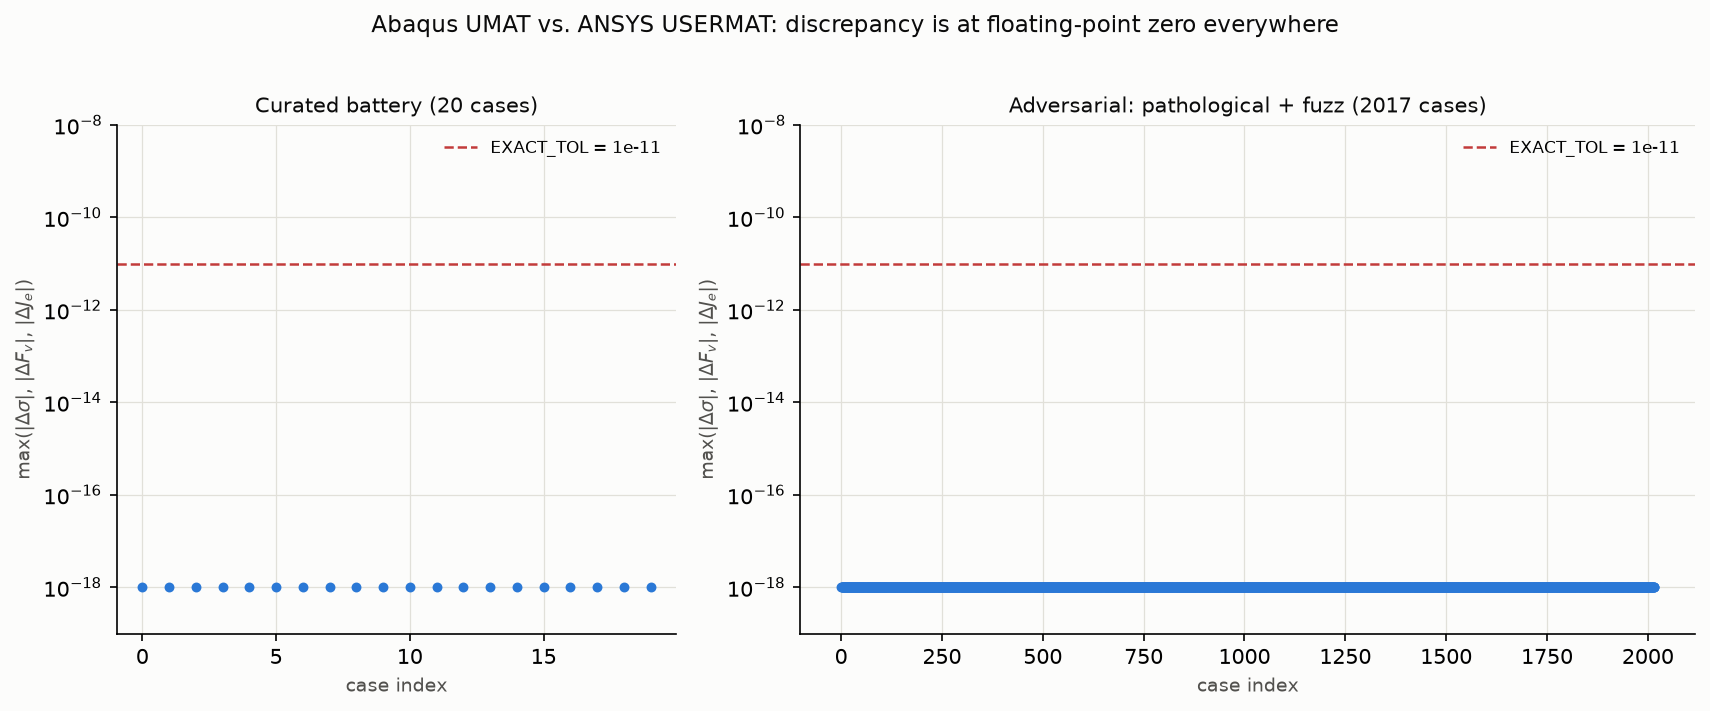

In [4]:
curated_d = np.array([max(r[1:]) for r in curated_rows])
plot_floor = 1e-18  # log-scale can't show exact 0.0

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), dpi=150, gridspec_kw={"width_ratios": [1, 1.6]})
fig.patch.set_facecolor(SURFACE)

for ax, data, title in [
    (axes[0], curated_d, f"Curated battery ({len(curated_d)} cases)"),
    (axes[1], deltas, f"Adversarial: pathological + fuzz ({len(deltas)} cases)"),
]:
    ax.set_facecolor(SURFACE)
    y = np.maximum(data, plot_floor)
    ax.scatter(np.arange(len(y)), y, s=14, color=BLUE, zorder=3)
    ax.axhline(adversarial.EXACT_TOL, color=BAD, linestyle="--", linewidth=1.2, zorder=2,
               label=f"EXACT_TOL = {adversarial.EXACT_TOL:.0e}")
    ax.set_yscale("log")
    ax.set_ylim(plot_floor / 10, 1e-8)
    ax.set_xlabel("case index", fontsize=9, color=INK_SECONDARY)
    ax.set_ylabel(r"max(|$\Delta\sigma$|, |$\Delta F_v$|, |$\Delta J_e$|)", fontsize=9, color=INK_SECONDARY)
    ax.set_title(title, fontsize=10, color=INK_PRIMARY)
    ax.grid(True, color=GRID, linewidth=0.6, zorder=0)
    ax.legend(loc="upper right", fontsize=8, frameon=False)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Abaqus UMAT vs. ANSYS USERMAT: discrepancy is at floating-point zero everywhere",
             fontsize=11, color=INK_PRIMARY, y=1.02)
fig.tight_layout()
plt.show()

## A real bug this harness caught / この検証が実際に捕まえたバグ

**EN.** The initial ANSYS port applied the Mooney-Rivlin `C01` term only to
the final Cauchy stress, not to the viscous flow driver as the Abaqus
reference does -- so `Fv` evolved differently for `mtype=1, eta>0`. This
cross-check caught it (a nonzero `|dFv|` on the Mooney-Rivlin case); it is
now fixed and bit-identical. Since the top-level tangent in both cores is a
finite-difference of this same stress function, core equivalence implies
tangent equivalence too -- one check covers both.

**JA.** 初期のANSYS移植版は、Mooney-Rivlinの`C01`項を最終的なコーシー応力
にのみ適用しており、Abaqusリファレンスのように粘性流れのドライバには適用
していませんでした -- そのため`mtype=1, eta>0`で`Fv`の発展が異なっていま
した。このクロスチェックがそれを検出し(Mooney-Rivlinケースで`|dFv|`が
非ゼロに)、現在は修正されbit-identicalです。両コアの上位レベルの接線剛性
はいずれもこの同じ応力関数の有限差分であるため、コアの一致は接線剛性の
一致も意味します -- 1つの検証で両方をカバーできます。